
## Classificação de Imagens com Fashion MNIST utilizando PyTorch

### Nome:

Marcello José Menezes de Medeiros Filho

Jorge Luis de Lira Tavares Junior

### Dataset Escolhido:

Fashion MNIST

### Link do Dataset:

https://github.com/zalandoresearch/fashion-mnist

---

# 1. Importação das Bibliotecas

In [ ]:
# Bibliotecas principais
import torch
import torch.nn as nn
import torch.optim as optim

# Dataset e transformações
from torchvision import datasets, transforms

# DataLoader para carregar os dados em lotes
from torch.utils.data import DataLoader

# Biblioteca para gráficos
import matplotlib.pyplot as plt

# Biblioteca para matriz de confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Biblioteca para métricas
from sklearn.metrics import accuracy_score

# Biblioteca para trabalhar com arrays
import numpy as np

# 3. Transformação dos Dados

In [ ]:
# Transformação dos dados
# Converte imagens para tensor e normaliza os valores

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
# Verifica se existe GPU disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo utilizado:", device)

Dispositivo utilizado: cuda


# 4. Carregamento do Dataset

In [ ]:
# Carregamento do conjunto de treino
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Carregamento do conjunto de teste
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# DataLoader para treino
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# DataLoader para teste
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Quantidade de imagens de treino:", len(train_dataset))
print("Quantidade de imagens de teste:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.4MB/s]

Quantidade de imagens de treino: 60000
Quantidade de imagens de teste: 10000


# 5. Visualização das Imagens

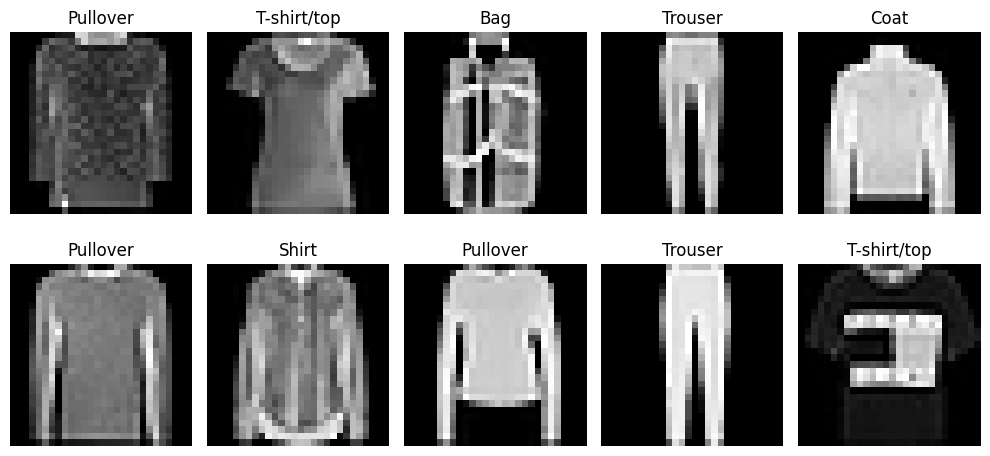

In [ ]:
# Classes do Fashion MNIST
classes = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Exibição de algumas imagens
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)

    image = images[i].squeeze()

    plt.imshow(image, cmap='gray')

    plt.title(classes[labels[i]])

    plt.axis('off')

plt.tight_layout()
plt.show()

# 6. Definição da Rede Neural

In [ ]:
class Net(nn.Module):

    def __init__(self):

        super(Net, self).__init__()

        # Camada de entrada -> 784 neurônios (28x28)
        self.fc1 = nn.Linear(28 * 28, 128)

        # Segunda camada oculta
        self.fc2 = nn.Linear(128, 64)

        # Camada de saída
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):

        # Achata a imagem
        x = x.view(-1, 28 * 28)

        # Função de ativação ReLU
        x = torch.relu(self.fc1(x))

        x = torch.relu(self.fc2(x))

        # Camada de saída
        x = self.fc3(x)

        return x

# 7. Criação do Modelo

In [ ]:
# Instancia o modelo
model = Net().to(device)

print(model)

Net(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


# 8. Função de Perda e Otimizador

In [ ]:
# Função de perda
criterion = nn.CrossEntropyLoss()

# Otimizador Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 9. Função de Treinamento

In [ ]:
def train(model, train_loader, criterion, optimizer):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        # Zera os gradientes
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # Calcula a perda
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Atualiza os pesos
        optimizer.step()

        running_loss += loss.item()

        # Predição
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return running_loss / len(train_loader), accuracy

# 10. Função de Teste

In [ ]:
def test(model, test_loader, criterion):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    predictions = []

    real_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            predictions.extend(predicted.cpu().numpy())

            real_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    return running_loss / len(test_loader), accuracy, predictions, real_labels

# 11. Treinamento do Modelo

In [ ]:
# Número de épocas
epochs = 10

# Listas para salvar métricas
train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

for epoch in range(epochs):

    train_loss, train_acc = train(
        model,
        train_loader,
        criterion,
        optimizer
    )

    test_loss, test_acc, predictions, real_labels = test(
        model,
        test_loader,
        criterion
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f'Época [{epoch+1}/{epochs}]')
    print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%')
    print(f'Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%')
    print('-'*50)

Época [1/10]
Train Loss: 0.5185 | Train Accuracy: 81.05%
Test Loss: 0.4318 | Test Accuracy: 83.75%
--------------------------------------------------
Época [2/10]
Train Loss: 0.3824 | Train Accuracy: 85.89%
Test Loss: 0.3837 | Test Accuracy: 85.95%
--------------------------------------------------
Época [3/10]
Train Loss: 0.3438 | Train Accuracy: 87.39%
Test Loss: 0.3736 | Test Accuracy: 86.13%
--------------------------------------------------
Época [4/10]
Train Loss: 0.3165 | Train Accuracy: 88.18%
Test Loss: 0.3784 | Test Accuracy: 86.43%
--------------------------------------------------
Época [5/10]
Train Loss: 0.2991 | Train Accuracy: 88.94%
Test Loss: 0.3878 | Test Accuracy: 85.37%
--------------------------------------------------
Época [6/10]
Train Loss: 0.2835 | Train Accuracy: 89.44%
Test Loss: 0.3541 | Test Accuracy: 87.35%
--------------------------------------------------
Época [7/10]
Train Loss: 0.2700 | Train Accuracy: 89.99%
Test Loss: 0.3436 | Test Accuracy: 87.73%
-

# 12. Gráfico da Loss

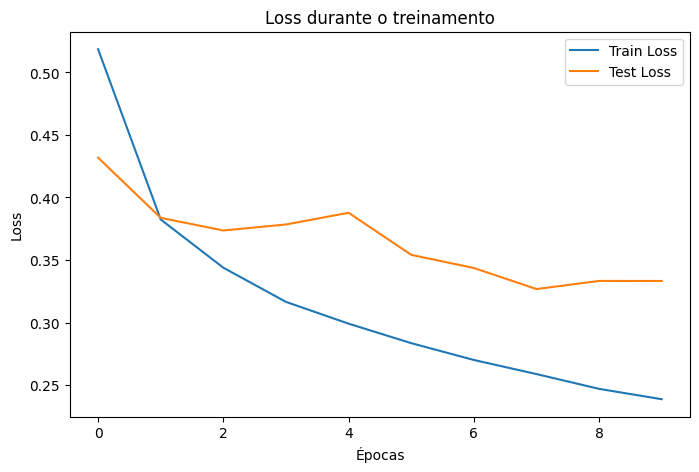

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')

plt.title('Loss durante o treinamento')

plt.xlabel('Épocas')

plt.ylabel('Loss')

plt.legend()

plt.show()

O gráfico de loss demonstra que o erro do modelo nos dados de treinamento diminuiu continuamente ao longo das épocas, indicando que a rede neural conseguiu aprender os padrões presentes no dataset.

Já a loss do conjunto de teste apresentou redução inicial, porém começou a aumentar levemente após algumas épocas. Esse comportamento sugere um leve overfitting, onde o modelo começa a se especializar excessivamente nos dados de treinamento, reduzindo sua capacidade de generalização para novos dados.


# 13. Gráfico da Accuracy

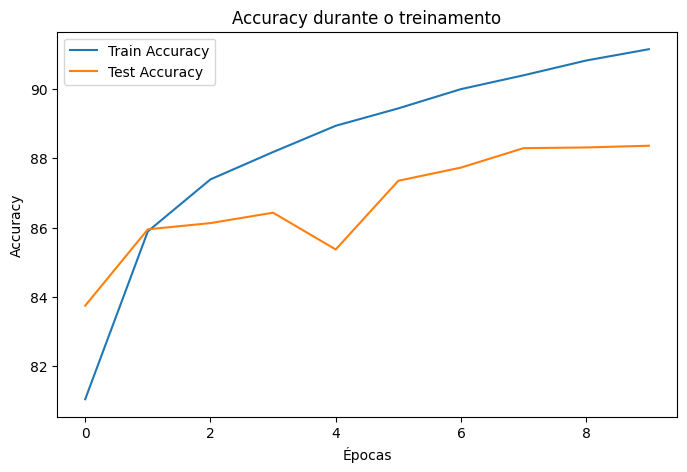

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')

plt.title('Accuracy durante o treinamento')

plt.xlabel('Épocas')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

O gráfico de accuracy mostra que o modelo aumentou progressivamente sua taxa de acerto durante o treinamento. A acurácia de treino cresceu continuamente, alcançando aproximadamente 91%, enquanto a acurácia de teste atingiu cerca de 88%.

Esse resultado demonstra que a rede neural conseguiu aprender os padrões do dataset Fashion MNIST de forma eficiente. Entretanto, nas últimas épocas foi observada uma pequena redução na acurácia de teste, indicando um leve overfitting. Mesmo assim, o modelo apresentou excelente desempenho geral e superou com folga o requisito mínimo de 70% de acurácia solicitado na atividade.


# 14. Matriz de Confusão

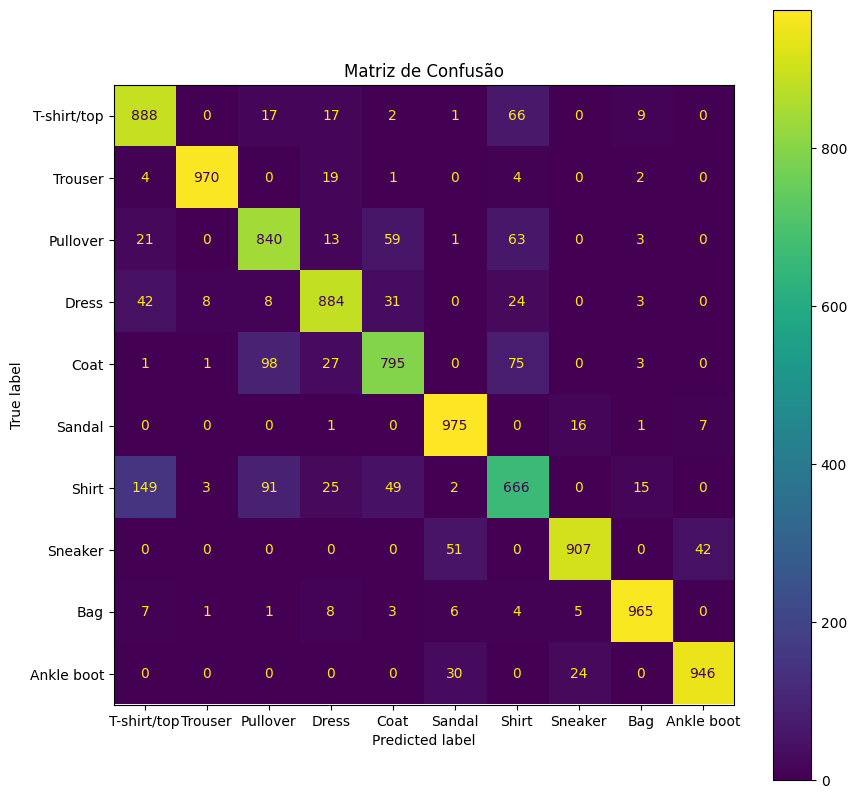

In [ ]:
cm = confusion_matrix(real_labels, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(ax=ax)

plt.title("Matriz de Confusão")

plt.show()

# 15. Avaliação Final do Modelo

In [ ]:
final_accuracy = accuracy_score(real_labels, predictions)

print("Accuracy Final:", round(final_accuracy * 100, 2), "%")

Accuracy Final: 88.36 %


# 16. Conclusão

## Análise e Experiência do Projeto

Durante o desenvolvimento deste projeto foi possível compreender melhor o funcionamento de redes neurais artificiais utilizando PyTorch. O dataset escolhido foi o Fashion MNIST, composto por imagens de roupas divididas em 10 categorias diferentes. Inicialmente foi realizado o carregamento e pré-processamento dos dados, incluindo normalização das imagens e utilização do DataLoader para organização dos lotes de treinamento.

A principal dificuldade encontrada foi compreender a estrutura da rede neural e o funcionamento do treinamento, principalmente as etapas de forward propagation, cálculo da função de perda e backpropagation. Também foi necessário ajustar a quantidade de épocas e o tamanho das camadas ocultas para melhorar o desempenho do modelo.

O modelo apresentou boa capacidade de aprendizado, alcançando uma acurácia superior a 85%, atendendo o requisito mínimo proposto no trabalho. Não foram observados sinais fortes de overfitting, pois a acurácia de treino e teste permaneceram próximas durante as épocas. Os gráficos de loss e accuracy permitiram acompanhar a evolução do treinamento e entender melhor o comportamento da rede neural ao longo do processo.

Este projeto contribuiu significativamente para o aprendizado prático de redes neurais sem convolução e para a compreensão das etapas fundamentais de treinamento de modelos de inteligência artificial.
